In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from utils.tools import aggregate_results

In [3]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def capitalize(s):
    return s[0].upper() + s[1:]

def order_suites(strings):
    return sorted(strings, key=lambda s: (
        s.split('-')[2],  # implicit-excplict
        s.split('-')[0],  # num demos
        s.split('-')[1],  # demo type
    ))

def order_models(strings):
    return sorted(strings, key=lambda s: (
        int(s.split('-')[1][:-1]),  # Param count, B dropped
        #s.split('-')[0],  # Model name
    ), reverse=True)

In [4]:
def heatmap(df, metric_cols):
    fig, axes = plt.subplots(len(metric_cols), 1, figsize=(10, 15), sharex=True, sharey=True)

    for i, ax in enumerate(axes):

        label, metric, *_ = metric_cols[i].split(" ")

        pivoted = df.pivot(index='model', columns='suite', values=metric_cols[i])
        pivoted = pivoted.reindex(order_suites(pivoted.columns), axis=1)
        pivoted = pivoted.reindex(order_models(pivoted.index), axis=0)
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            fmt=".2g",
            annot=True,
            square=True,
            cmap="Blues",
            ax=ax,
            cbar=False
        )

        if i == 2:
            # Rotate xticks
            ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

    mappable = ax.get_children()[0]
    plt.colorbar(mappable, ax=axes, orientation = 'vertical')

    return fig, ax

In [5]:
def my_heatmap(df, metric_cols):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

    plot_ax = [axes[0, 0], axes[0, 1], axes[1, 0]]

    for i, ax in enumerate(plot_ax):

        label, metric, *_ = metric_cols[i].split(" ")

        pivoted = df.pivot(index='model', columns='suite', values=metric_cols[i])
        pivoted = pivoted.reindex(order_suites(pivoted.columns), axis=1)
        pivoted = pivoted.reindex(order_models(pivoted.index), axis=0)
        
        ax.set_title(capitalize(label))
        
        sns.heatmap(
            pivoted,
            fmt=".2g",
            annot=True,
            square=True,
            cmap="Blues",
            ax=ax,
            cbar=False
        )

        if i == 2:
            # Rotate xticks
            ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

    # Move plots
    topright = plot_ax[1]
    pos = topright.get_position()
    pos.x0 = pos.x0 - 0.05
    pos.x1 = pos.x1 - 0.05
    topright.set_position(pos)

    bottomleft = plot_ax[2]
    pos = bottomleft.get_position()
    pos.x0 = pos.x0 + 0.185
    pos.x1 = pos.x1 + 0.185
    bottomleft.set_position(pos)

    plt.axis("off")

    mappable = ax.get_children()[0]
    #plt.colorbar(mappable, ax=axes, orientation = 'horizontal')

    return fig, ax

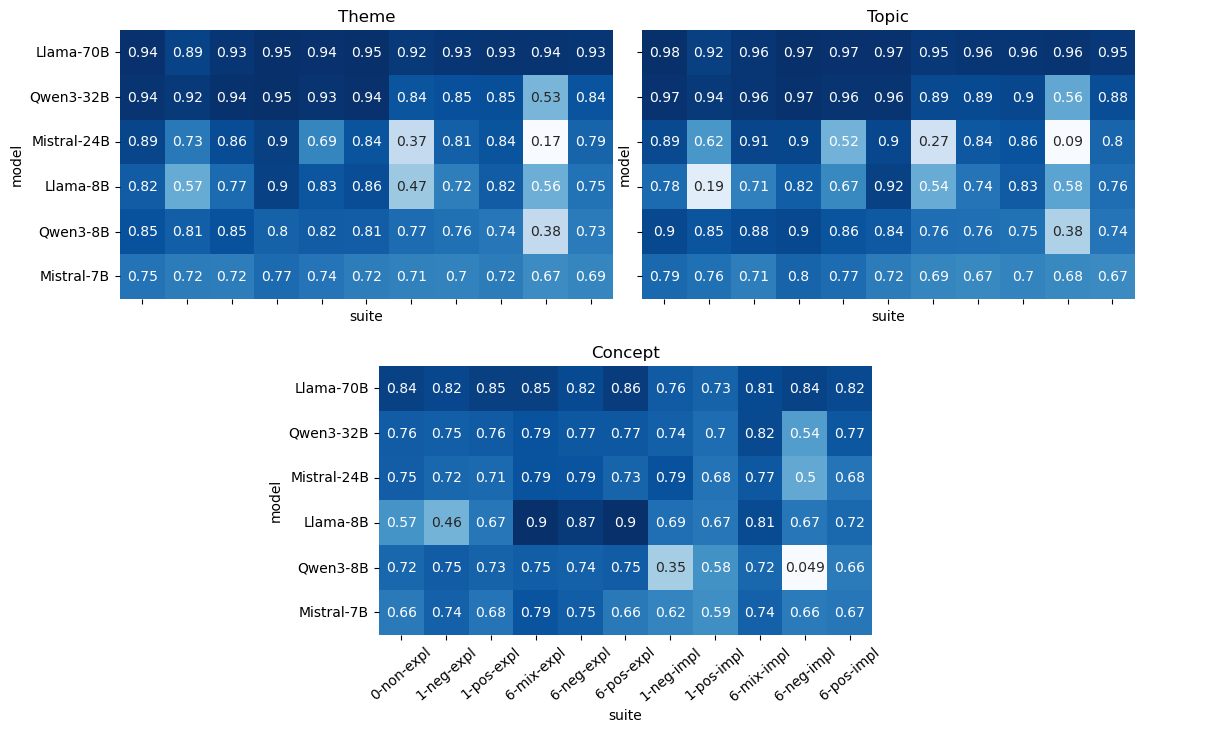

In [6]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

###
# HEATMAP F1
###
res = pd.read_csv("./data/metrics.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

fig, ax = my_heatmap(res, metric_cols_f1)
plt.savefig("./latex/images/f1_per_suite_v2", bbox_inches="tight")

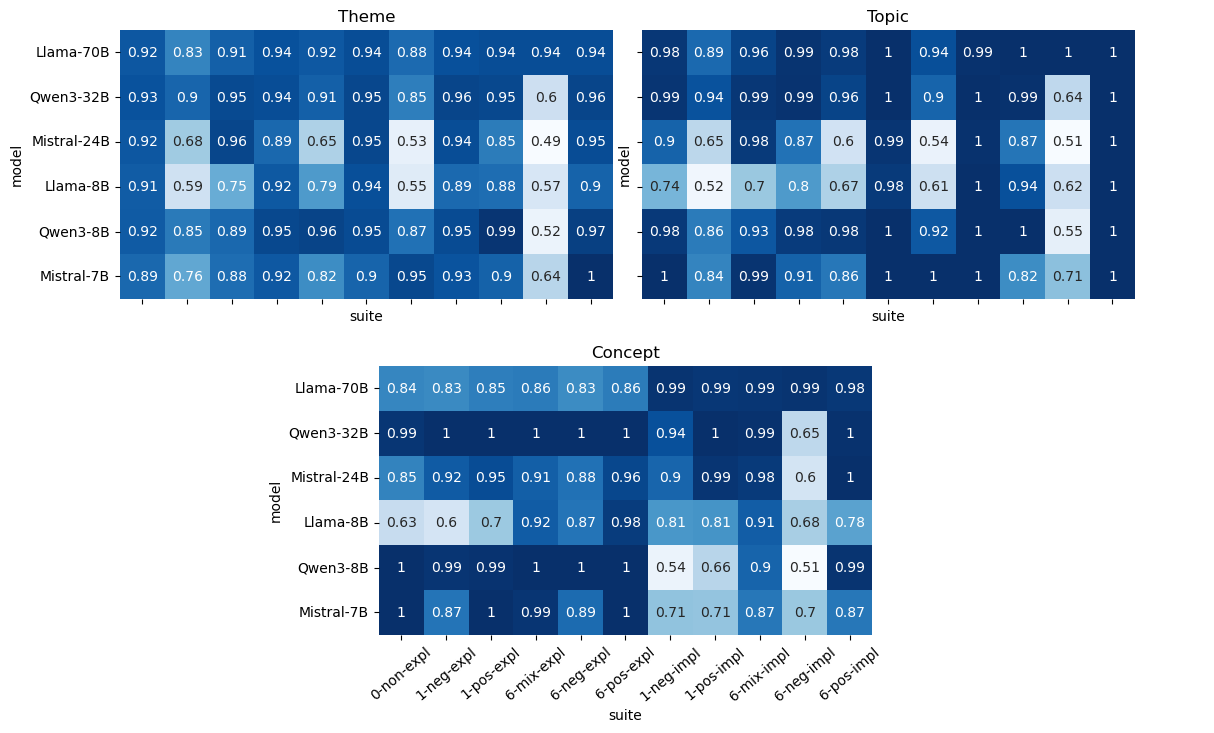

In [7]:
fig, ax = my_heatmap(res, metric_cols_prec)
plt.savefig("./latex/images/precision_per_suite_v2", bbox_inches="tight")

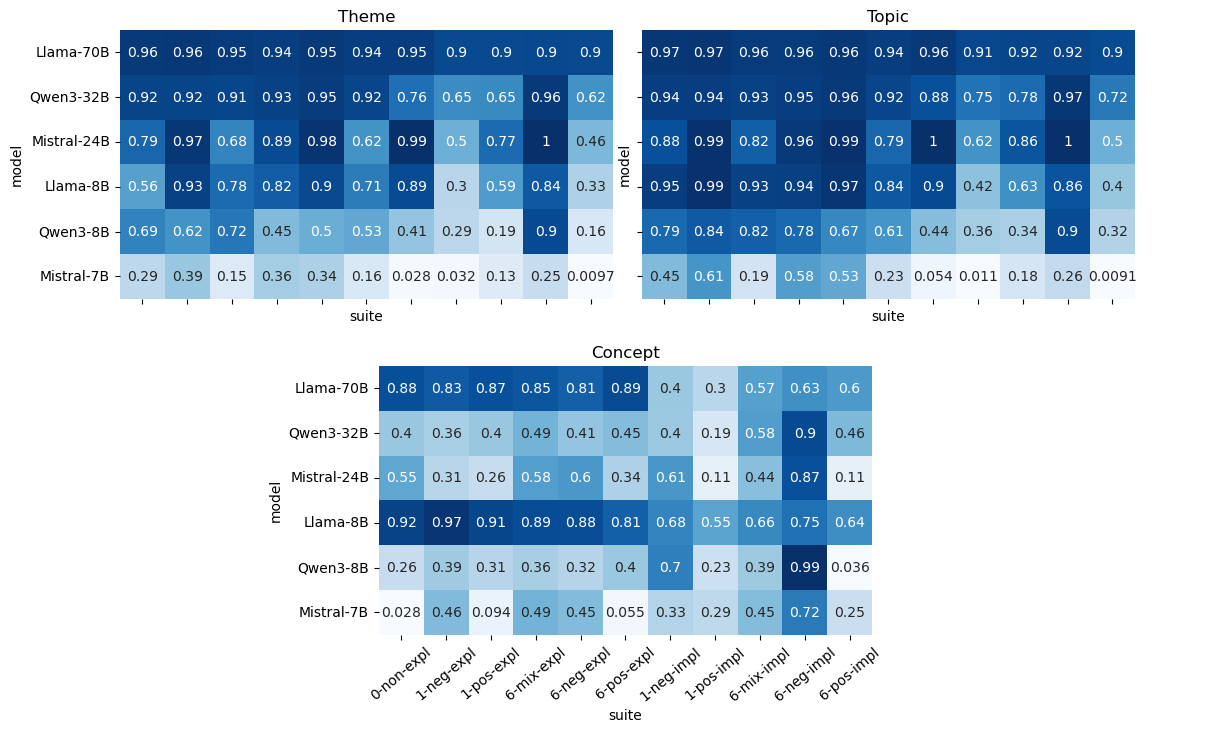

In [8]:
fig, ax = my_heatmap(res, metric_cols_rec)
plt.savefig("./latex/images/recall_per_suite_v2", bbox_inches="tight")

In [9]:
metric_cols = ["Theme", "Topic", "Concept", "Sum"]

f1s = res[["model", "suite"] + metric_cols_f1]
f1s = f1s.rename(columns={col: col.split(" ")[0] for col in metric_cols_f1})

f1s["sum"] = f1s["theme"] + f1s["topic"] + f1s["concept"]
f1s = f1s.rename(columns={col: capitalize(col) for col in f1s.columns})


top10s = [
    f1s
        .sort_values(by=col, ascending=False)[:10]
    for col in metric_cols
]

for df in top10s:
    print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrrrr}
\toprule
Model & Suite & Theme & Topic & Concept & Sum \\
\midrule
Llama-70B & 6-pos-expl & 0.949 & 0.972 & 0.859 & 2.780 \\
Qwen3-32B & 6-mix-expl & 0.946 & 0.971 & 0.787 & 2.704 \\
Llama-70B & 6-mix-expl & 0.946 & 0.974 & 0.850 & 2.770 \\
Llama-70B & 0-non-expl & 0.945 & 0.978 & 0.843 & 2.765 \\
Qwen3-32B & 6-pos-expl & 0.945 & 0.961 & 0.769 & 2.674 \\
Llama-70B & 6-neg-expl & 0.945 & 0.973 & 0.817 & 2.734 \\
Qwen3-32B & 1-pos-expl & 0.941 & 0.960 & 0.759 & 2.661 \\
Llama-70B & 6-neg-impl & 0.936 & 0.962 & 0.839 & 2.737 \\
Qwen3-32B & 0-non-expl & 0.936 & 0.966 & 0.757 & 2.659 \\
Llama-70B & 6-mix-impl & 0.935 & 0.960 & 0.814 & 2.709 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
Model & Suite & Theme & Topic & Concept & Sum \\
\midrule
Llama-70B & 0-non-expl & 0.945 & 0.978 & 0.843 & 2.765 \\
Llama-70B & 6-mix-expl & 0.946 & 0.974 & 0.850 & 2.770 \\
Llama-70B & 6-neg-expl & 0.945 & 0.973 & 0.817 & 2.734 \\
Llama-70B & 6-pos-expl & 0.949 & 0.97

In [10]:
max_per_model = f1s.groupby('Model').idxmax()["Sum"]
tops_per_model = [
    f1s
        .loc[max_per_model]
        .sort_values(by=col, ascending=False)
    for col in metric_cols
]

for df in tops_per_model:
    print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{llrrrr}
\toprule
Model & Suite & Theme & Topic & Concept & Sum \\
\midrule
Llama-70B & 6-pos-expl & 0.949 & 0.972 & 0.859 & 2.780 \\
Qwen3-32B & 6-mix-expl & 0.946 & 0.971 & 0.787 & 2.704 \\
Mistral-24B & 6-mix-expl & 0.903 & 0.905 & 0.790 & 2.598 \\
Llama-8B & 6-pos-expl & 0.863 & 0.918 & 0.898 & 2.679 \\
Qwen3-8B & 0-non-expl & 0.851 & 0.897 & 0.718 & 2.466 \\
Mistral-7B & 6-mix-expl & 0.770 & 0.799 & 0.786 & 2.355 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
Model & Suite & Theme & Topic & Concept & Sum \\
\midrule
Llama-70B & 6-pos-expl & 0.949 & 0.972 & 0.859 & 2.780 \\
Qwen3-32B & 6-mix-expl & 0.946 & 0.971 & 0.787 & 2.704 \\
Llama-8B & 6-pos-expl & 0.863 & 0.918 & 0.898 & 2.679 \\
Mistral-24B & 6-mix-expl & 0.903 & 0.905 & 0.790 & 2.598 \\
Qwen3-8B & 0-non-expl & 0.851 & 0.897 & 0.718 & 2.466 \\
Mistral-7B & 6-mix-expl & 0.770 & 0.799 & 0.786 & 2.355 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
Model & Suite & Theme & Topic & C